In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

ANALYSIS_FILE = 'sample_data/complexity_analysis.csv'
POINTS_FILE = 'sample_data/last_points_export.csv'

In [8]:
def load_data(file_path):
    """Tenta carregar um arquivo CSV e retorna o DataFrame."""
    if not os.path.exists(file_path):
        print(f"ERRO: Arquivo '{file_path}' não encontrado. Por favor, faça upload para o Colab.")
        return None
    try:
        df = pd.read_csv(file_path)
        print(f"Arquivo '{file_path}' carregado com sucesso. Linhas: {len(df)}")
        return df
    except Exception as e:
        print(f"ERRO ao ler o arquivo {file_path}: {e}")
        return None


In [9]:
df_comp = load_data(ANALYSIS_FILE)

Arquivo 'sample_data/complexity_analysis.csv' carregado com sucesso. Linhas: 9


In [10]:
df_comp['nlogn'] = df_comp['n_points'] * np.log10(df_comp['n_points'])

In [11]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

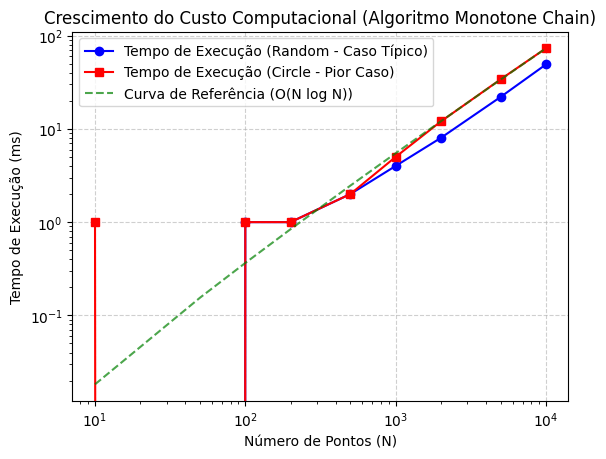

In [19]:
plt.plot(df_comp['n_points'], df_comp['time_ms_random'], marker='o',
             label='Tempo de Execução (Random - Caso Típico)', color='blue')
plt.plot(df_comp['n_points'], df_comp['time_ms_circle'], marker='s',
             label='Tempo de Execução (Circle - Pior Caso)', color='red')
scale_factor = df_comp['time_ms_circle'].iloc[-1] / df_comp['nlogn'].iloc[-1]
plt.plot(df_comp['n_points'], df_comp['nlogn'] * scale_factor, linestyle='--',
             label='Curva de Referência (O(N log N))', color='green', alpha=0.7)
plt.title('Crescimento do Custo Computacional (Algoritmo Monotone Chain)')
plt.xlabel('Número de Pontos (N)')
plt.ylabel('Tempo de Execução (ms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xscale('log') # Escala logarítmica para melhor visualização
plt.yscale('log')
plt.show()

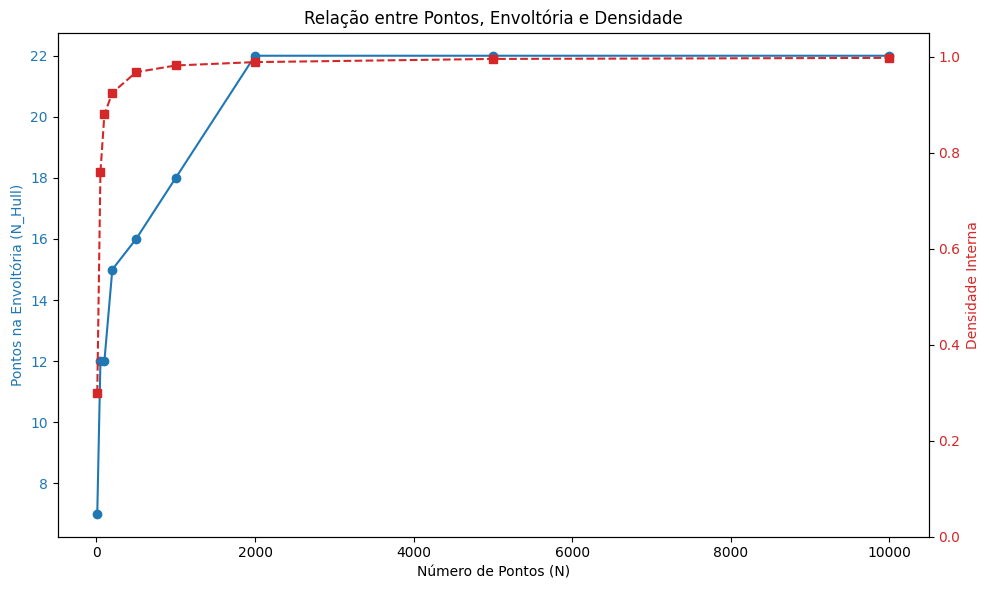

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Esquerdo: Número de Pontos no Hull
color = 'tab:blue'
ax1.set_xlabel('Número de Pontos (N)')
ax1.set_ylabel('Pontos na Envoltória (N_Hull)', color=color)
ax1.plot(df_comp['n_points'], df_comp['n_hull_random'], marker='o',
          linestyle='-', color=color, label='N_Hull (Random)')
ax1.tick_params(axis='y', labelcolor=color)

# Eixo Direito: Densidade de Pontos Internos (apenas para Random)
ax2 = ax1.twinx()  # Cria um segundo eixo que compartilha o eixo x
color = 'tab:red'
ax2.set_ylabel('Densidade Interna', color=color)
ax2.plot(df_comp['n_points'], df_comp['density_random'], marker='s',
          linestyle='--', color=color, label='Densidade (Random)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.05) # A densidade deve estar entre 0 e 1

plt.title('Relação entre Pontos, Envoltória e Densidade')
fig.tight_layout()
plt.show()

In [21]:
df_points = load_data(POINTS_FILE)

Arquivo 'sample_data/last_points_export.csv' carregado com sucesso. Linhas: 32


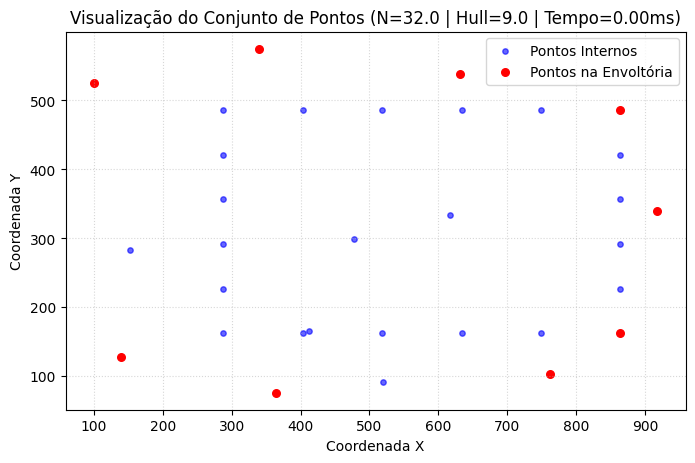

In [22]:
plt.figure(figsize=(8, 8))

# Pontos internos
internal = df_points[df_points['is_hull'] == 0]
# Pontos na Envoltória
hull_points = df_points[df_points['is_hull'] == 1]

plt.scatter(internal['x'], internal['y'], color='blue', alpha=0.6, s=15, label='Pontos Internos')
plt.scatter(hull_points['x'], hull_points['y'], color='red', alpha=1.0, s=30, label='Pontos na Envoltória')

# Metadados no Título
meta_data = df_points.iloc[0]
n_points = meta_data['n_points']
n_hull = meta_data['n_hull']
elapsed = meta_data['elapsed_ms']

plt.title(f'Visualização do Conjunto de Pontos (N={n_points} | Hull={n_hull} | Tempo={elapsed:.2f}ms)')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()